# Análise Exploratória de Dados — Manutenção Preditiva de Motores

**Sprint 2** | Classificação multiclasse de falhas em motores industriais

Este notebook realiza a análise exploratória completa da base `motor.db`, preparando o
terreno para o treinamento do modelo baseline. Cada seção inclui visualizações e
interpretações que ligam os padrões observados ao comportamento físico esperado nos
motores industriais.

**Sumário:**
1. Inspeção Geral da Base
2. Distribuição da Variável-Alvo
3. Distribuição dos Sensores por Classe de Falha
4. Evolução Temporal — Rampa de Deterioração
5. Correlação entre Sensores
6. Detecção de Outliers
7. Variabilidade entre Motores
8. Pairplot — Separabilidade das Classes


In [1]:
import sqlite3
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

conn = sqlite3.connect('motor.db')
df = pd.read_sql("""
    SELECT l.id, l.motor_id, l.timestamp,
           l.rotacao_rpm, l.vibracao_mm_s, l.temperatura_c, l.corrente_a,
           l.falha, m.fabricante, m.modelo, m.potencia_kw
    FROM leituras l
    JOIN motores m ON l.motor_id = m.id
    ORDER BY l.motor_id, l.timestamp
""", conn)
conn.close()

df['timestamp']  = pd.to_datetime(df['timestamp'])
df['falha_nome'] = df['falha'].map({
    0: 'Normal', 1: 'Desbalanceamento',
    2: 'Superaquecimento', 3: 'Falha Mecanica'
})

SENSOR_COLS = ['rotacao_rpm', 'vibracao_mm_s', 'temperatura_c', 'corrente_a']
LABELS      = ['Normal', 'Desbalanceamento', 'Superaquecimento', 'Falha Mecanica']
CORES       = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0']
NOMINAIS    = {'rotacao_rpm': 1750, 'vibracao_mm_s': 2.5,
               'temperatura_c': 65, 'corrente_a': 12}

print(f"Banco carregado: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.head(3)


Banco carregado: 30,000 linhas x 12 colunas


,id,motor_id,timestamp,rotacao_rpm,vibracao_mm_s,temperatura_c,corrente_a,falha,fabricante,modelo,potencia_kw,falha_nome
0,1,1,2023-01-01 00:00:00,1781.36,2.799,74.98,12.646,0,Schneider,X100,17.8,Normal
1,2,1,2023-01-01 00:10:00,1771.91,2.250,74.17,12.520,0,Schneider,X100,17.8,Normal
2,3,1,2023-01-01 00:20:00,1777.03,2.327,71.15,12.943,0,Schneider,X100,17.8,Normal


## 1. Inspeção Geral da Base

In [2]:
print("=== Shape ===")
print(f"Linhas: {len(df):,}  |  Colunas: {df.shape[1]}")

print("\n=== Valores nulos ===")
nulos = df[SENSOR_COLS + ['falha']].isnull().sum()
print(nulos)
print("=> Nenhum valor nulo: sem necessidade de imputação.")

print("\n=== Estatísticas descritivas ===")
display(df[SENSOR_COLS].describe().round(2))


=== Shape ===
Linhas: 30,000  |  Colunas: 12

=== Valores nulos ===
rotacao_rpm      0
vibracao_mm_s    0
temperatura_c    0
corrente_a       0
falha            0
dtype: int64
=> Nenhum valor nulo: sem necessidade de imputação.

=== Estatísticas descritivas ===


,rotacao_rpm,vibracao_mm_s,temperatura_c,corrente_a
count,30000.00,30000.00,30000.00,30000.00
mean,1753.04,2.79,68.09,12.55
std,33.43,1.35,7.38,1.16
min,1595.81,1.54,53.09,9.32
25%,1728.66,2.33,62.49,11.82
50%,1753.26,2.51,67.25,12.47
75%,1778.89,2.71,72.52,13.14
max,1941.94,12.89,115.00,21.18


## 2. Distribuição da Variável-Alvo

O banco apresenta **forte desbalanceamento de classes**, padrão típico de aplicações
reais de manutenção preditiva: falhas são eventos raros em operação normal.
Esse desequilíbrio exige estratégias específicas no treinamento — como
`class_weight='balanced'` — e demanda avaliação prioritária por **F1-Macro** e
**Recall nas classes minoritárias**, não pela acurácia global.


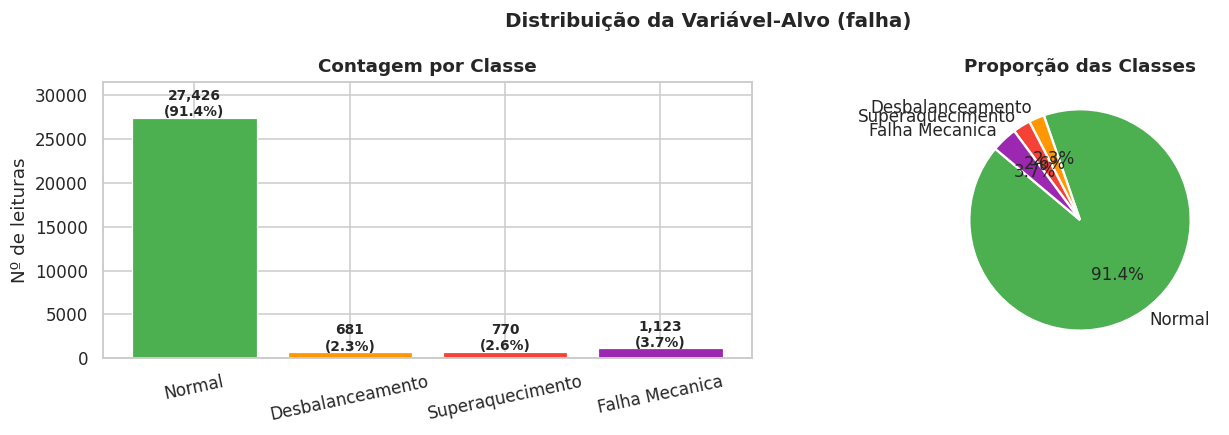

In [3]:
counts = df['falha_nome'].value_counts().reindex(LABELS)
pcts   = counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barras
bars = axes[0].bar(counts.index, counts.values, color=CORES, edgecolor='white', linewidth=0.8)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 200, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Contagem por Classe', fontweight='bold')
axes[0].set_ylabel('Nº de leituras')
axes[0].tick_params(axis='x', rotation=12)
axes[0].set_ylim(0, counts.max() * 1.15)

# Pizza
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=CORES, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.suptitle('Distribuição da Variável-Alvo (falha)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_distribuicao_classes.png', bbox_inches='tight')
plt.show()


**Interpretação:**
- A classe **Normal (0)** representa **91,4%** das leituras — dominância típica de séries
  industriais onde falhas são eventos raros.
- As três classes de falha somam apenas **8,6%** do total, distribuídas entre
  Desbalanceamento (2,3%), Superaquecimento (2,6%) e Falha Mecânica (3,7%).
- A razão de desbalanceamento chega a **1:40** (Normal vs. Desbalanceamento),
  o que torna a acurácia global uma métrica enganosa: um modelo que sempre prediz
  "Normal" atingiria ~91% de acurácia com F1-Macro de apenas ~23%.
- **Implicação prática:** o desempenho nas classes 1, 2 e 3 é o que determina o
  valor real da solução de manutenção preditiva.


## 3. Distribuição dos Sensores por Classe de Falha

Boxplots por classe revelam a **separabilidade** de cada sensor para cada tipo de falha —
informação essencial para entender quais sensores carregam mais sinal preditivo.


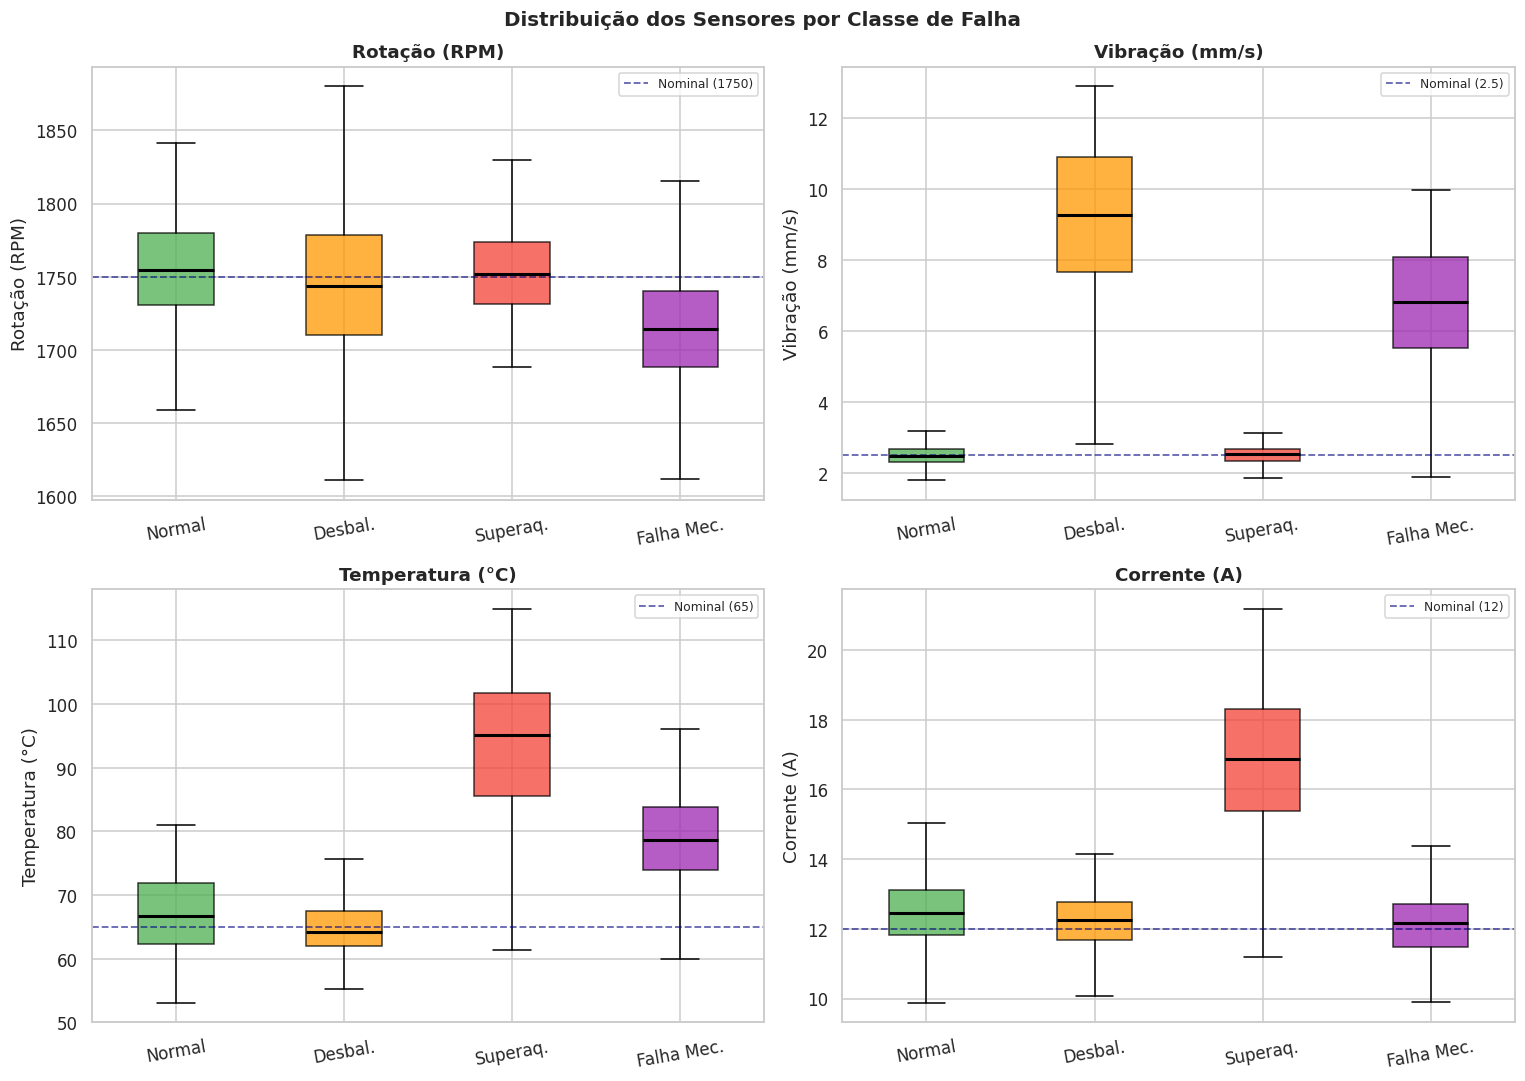

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
LABELS_CURTOS = ['Normal', 'Desbal.', 'Superaq.', 'Falha Mec.']
YLABELS = ['Rotação (RPM)', 'Vibração (mm/s)', 'Temperatura (°C)', 'Corrente (A)']

for ax, col, ylabel in zip(axes.flat, SENSOR_COLS, YLABELS):
    data = [df[df['falha'] == c][col].values for c in [0, 1, 2, 3]]
    bp = ax.boxplot(data, patch_artist=True, notch=False, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, cor in zip(bp['boxes'], CORES):
        patch.set_facecolor(cor)
        patch.set_alpha(0.75)
    # Linha de valor nominal
    ax.axhline(NOMINAIS[col], color='navy', linestyle='--', linewidth=1.2,
               alpha=0.6, label=f'Nominal ({NOMINAIS[col]})')
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(LABELS_CURTOS, rotation=10)
    ax.set_title(ylabel, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.suptitle('Distribuição dos Sensores por Classe de Falha', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_boxplot_sensores.png', bbox_inches='tight')
plt.show()


**Interpretação física de cada sensor:**

- **Vibração (mm/s):** o sensor mais discriminativo para **Desbalanceamento**.
  A mediana sobe para ~7–9 mm/s contra ~2,5 mm/s no Normal — desvio de +180% a +260%.
  Fisicamente, o desbalanceamento do rotor gera forças centrífugas que se propagam como
  vibração na estrutura do motor.

- **Temperatura (°C):** sensor dominante para **Superaquecimento**, com mediana acima de
  90°C contra ~65°C no Normal (+38%). Fisicamente, sobrecarga elétrica ou falha no
  sistema de resfriamento elevam a temperatura dos enrolamentos.

- **Corrente (A):** também sobe significativamente no Superaquecimento (~18A vs ~12A,
  +50%). A relação temperatura–corrente é física: maior corrente gera mais calor por
  efeito Joule (P = I²R), tornando esses dois sensores altamente correlacionados nessa classe.

- **Rotação (RPM):** a **Falha Mecânica** apresenta queda gradual de RPM além de vibração
  elevada. Fisicamente, o desgaste de rolamentos aumenta o atrito mecânico, reduzindo
  a velocidade angular sob carga constante. Isoladamente, a rotação tem menor poder
  discriminativo — seu valor está na combinação com vibração e temperatura.


## 4. Evolução Temporal — Rampa de Deterioração

Um dos desafios centrais da manutenção preditiva é detectar falhas **no início da
rampa de deterioração**, quando o desvio dos sensores ainda é sutil. O banco simula
uma rampa progressiva de 30 leituras (300 minutos) antes de cada falha atingir
amplitude máxima.


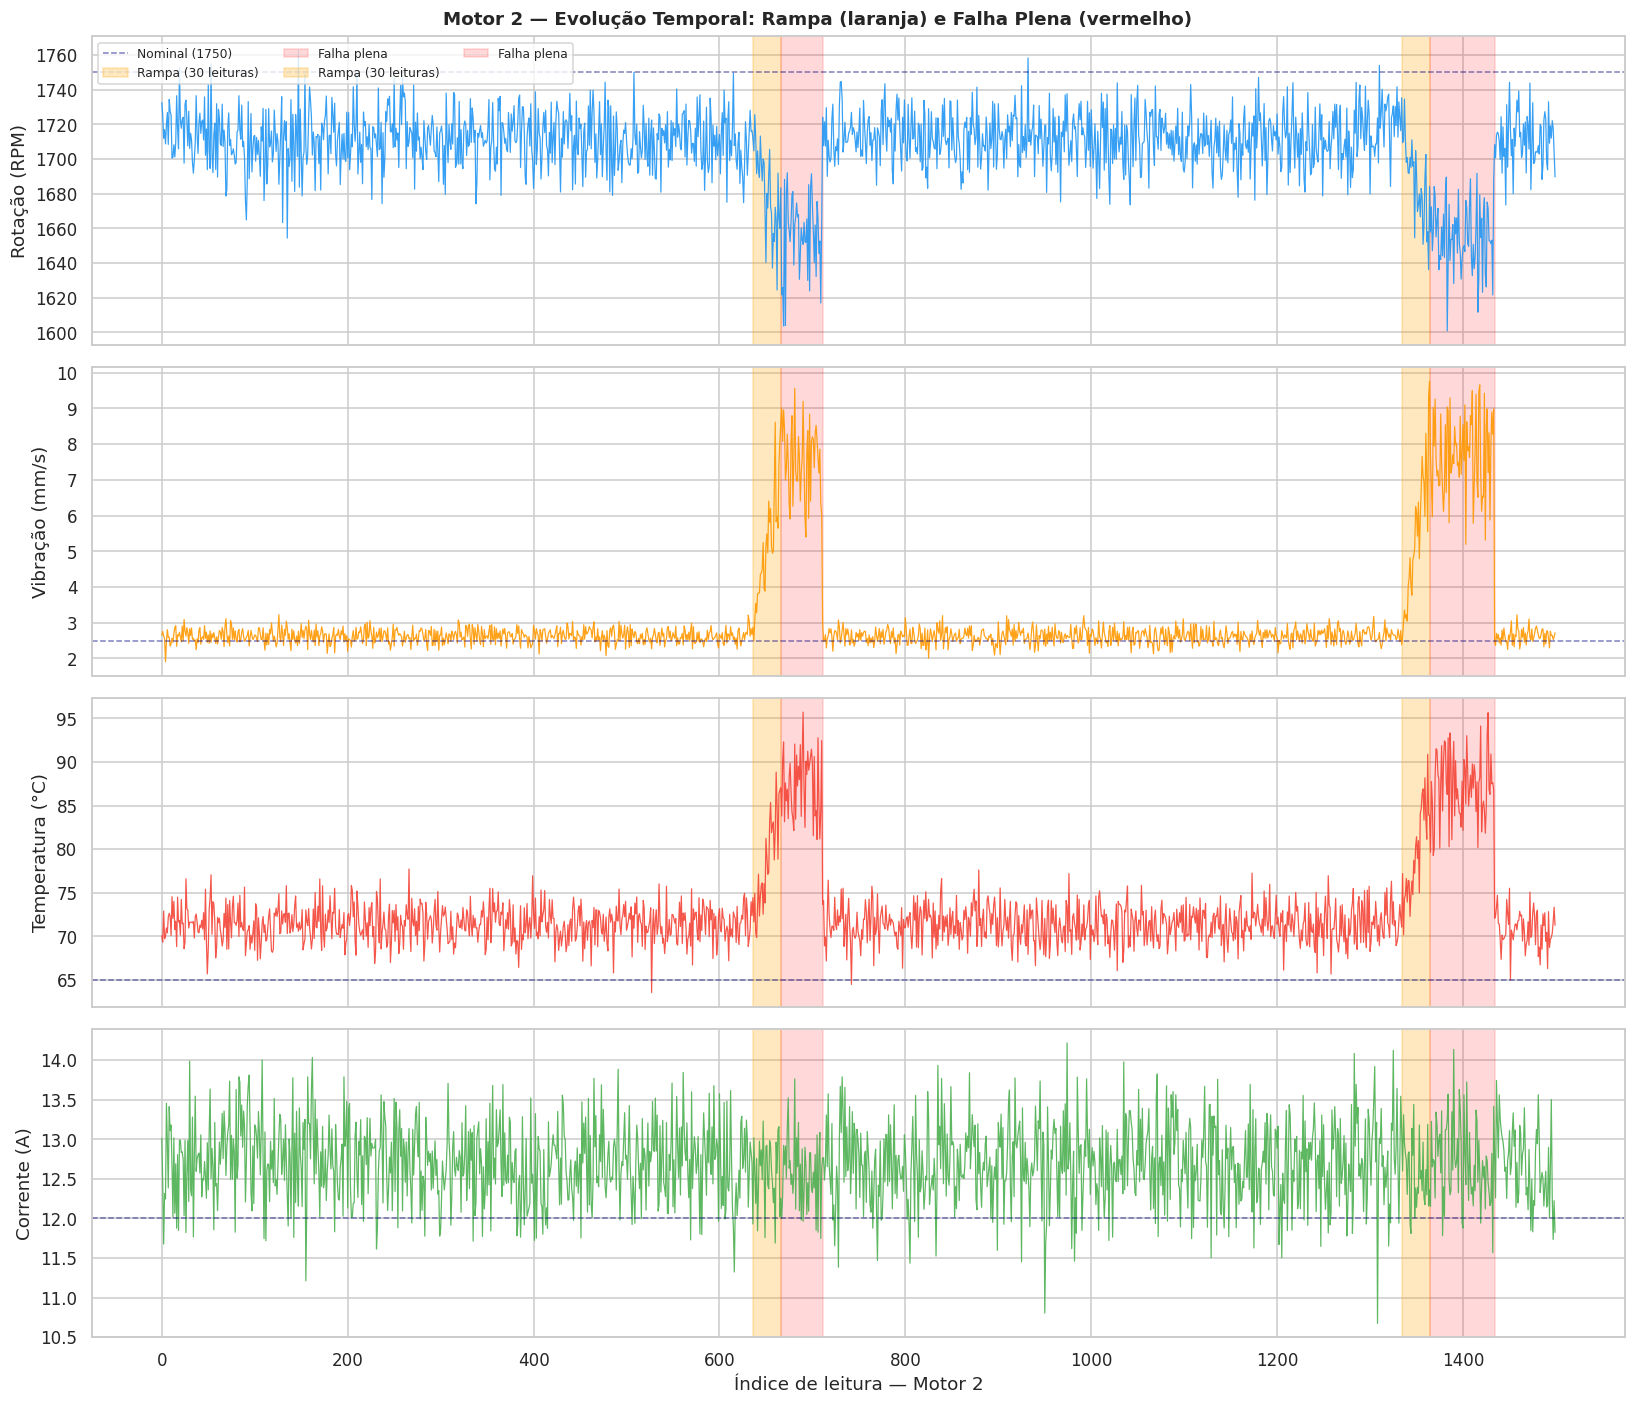

In [5]:
# Selecionar motor com falha mecânica para visualizar a rampa
motor_plot = None
for mid in range(1, 21):
    sub_t = df[df['motor_id'] == mid]
    if (sub_t['falha'] == 3).sum() > 60:
        motor_plot = mid
        break
if motor_plot is None:
    motor_plot = 1

sub = df[df['motor_id'] == motor_plot].copy().reset_index(drop=True)
sub['idx'] = range(len(sub))

fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)
YLABELS2 = ['Rotação (RPM)', 'Vibração (mm/s)', 'Temperatura (°C)', 'Corrente (A)']
CORES2   = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']

for ax, col, ylabel, clr in zip(axes, SENSOR_COLS, YLABELS2, CORES2):
    ax.plot(sub['idx'], sub[col], color=clr, linewidth=0.8, alpha=0.9)
    ax.axhline(NOMINAIS[col], color='navy', linestyle='--', linewidth=1, alpha=0.5,
               label=f'Nominal ({NOMINAIS[col]})')
    # Sombrear janelas de falha e destacar a rampa
    in_fault, start_i = False, 0
    for i in range(len(sub)):
        if sub.loc[i, 'falha'] != 0 and not in_fault:
            start_i = i; in_fault = True
        elif sub.loc[i, 'falha'] == 0 and in_fault:
            ax.axvspan(start_i, min(start_i + 30, i), alpha=0.25,
                       color='orange', label='Rampa (30 leituras)')
            ax.axvspan(min(start_i + 30, i), i, alpha=0.15,
                       color='red', label='Falha plena')
            in_fault = False
    if in_fault:
        ax.axvspan(start_i, min(start_i + 30, len(sub)-1), alpha=0.25, color='orange')
        ax.axvspan(min(start_i + 30, len(sub)-1), len(sub)-1, alpha=0.15, color='red')
    ax.set_ylabel(ylabel)
    # Mostrar legenda apenas na primeira subplot
    if col == SENSOR_COLS[0]:
        ax.legend(loc='upper left', fontsize=8, ncol=3)

axes[-1].set_xlabel(f'Índice de leitura — Motor {motor_plot}')
plt.suptitle(
    f'Motor {motor_plot} — Evolução Temporal: Rampa (laranja) e Falha Plena (vermelho)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_evolucao_temporal.png', bbox_inches='tight')
plt.show()


**Interpretação:**

- A **zona laranja** representa os primeiros 30 pontos de cada janela de falha —
  a **rampa de deterioração** onde o desvio dos sensores ainda é suave (0 a 100% da
  amplitude máxima). É aqui que o modelo tem maior dificuldade: o sinal ainda se
  confunde com o ruído normal de operação.

- A **zona vermelha** representa a falha em plena amplitude, onde os desvios são
  grandes e a classificação é mais fácil.

- O **desafio real de manutenção preditiva** é detectar a falha ainda na zona laranja —
  idealmente nas primeiras 10–15 leituras da rampa (~100–150 minutos de antecedência) —
  antes que o dano se torne irreversível. Essa é a principal motivação para as
  features de janela móvel (rolling mean e std) que capturam justamente essa tendência
  de subida gradual.


## 5. Correlação entre Sensores

A análise de correlação revela quais sensores se movem juntos, informando sobre
possível redundância de features e sobre os mecanismos físicos subjacentes de cada falha.


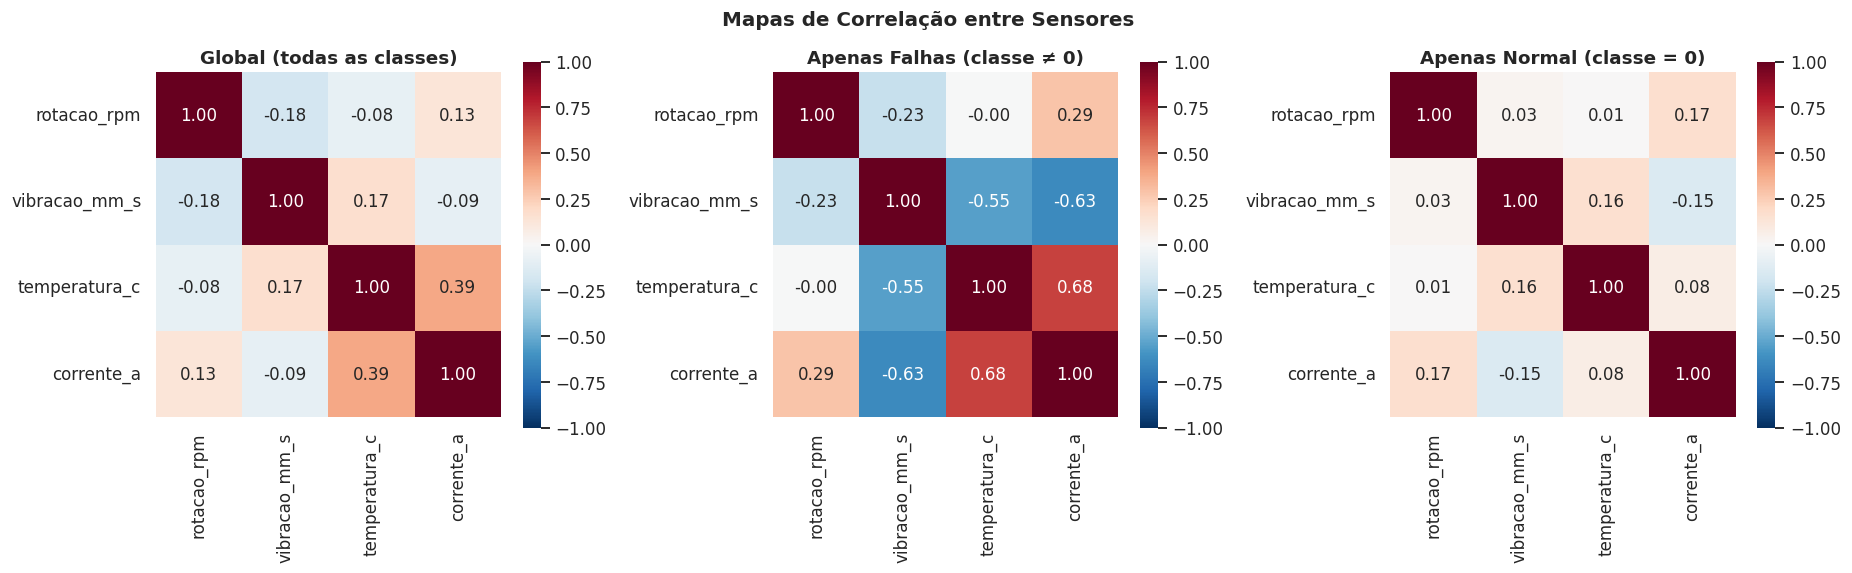

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

titulos  = ['Global (todas as classes)', 'Apenas Falhas (classe ≠ 0)', 'Apenas Normal (classe = 0)']
subsets  = [df, df[df['falha'] != 0], df[df['falha'] == 0]]

for ax, titulo, subset in zip(axes, titulos, subsets):
    corr = subset[SENSOR_COLS].corr()
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True   # mostrar triângulo superior
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=ax, square=True, vmin=-1, vmax=1,
                annot_kws={'size': 11})
    ax.set_title(titulo, fontweight='bold')

plt.suptitle('Mapas de Correlação entre Sensores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlacao.png', bbox_inches='tight')
plt.show()


**Interpretação:**

- **Temperatura × Corrente:** correlação positiva marcante **apenas nas janelas de falha**,
  ausente nos dados normais. Isso confirma o mecanismo físico do superaquecimento:
  excesso de corrente gera calor por efeito Joule. No Normal, esses dois sensores
  operam de forma independente.

- **Rotação × Vibração:** correlação negativa nas falhas — quando a rotação cai (Falha
  Mecânica por desgaste de rolamentos), a vibração sobe simultaneamente. Esse par de
  sensores em movimento oposto é o sinal mais característico da Falha Mecânica.

- **Correlação global baixa:** a ausência de correlação forte no dataset completo
  (dominado por dados normais) confirma que os sensores são razoavelmente independentes
  em operação regular. O Random Forest, que seleciona subconjuntos aleatórios de features
  a cada split, lida bem com a multicolinearidade presente apenas nas falhas.


## 6. Detecção de Outliers — Método IQR

Identifica valores atípicos nos sensores para decidir se devem ser tratados ou preservados.


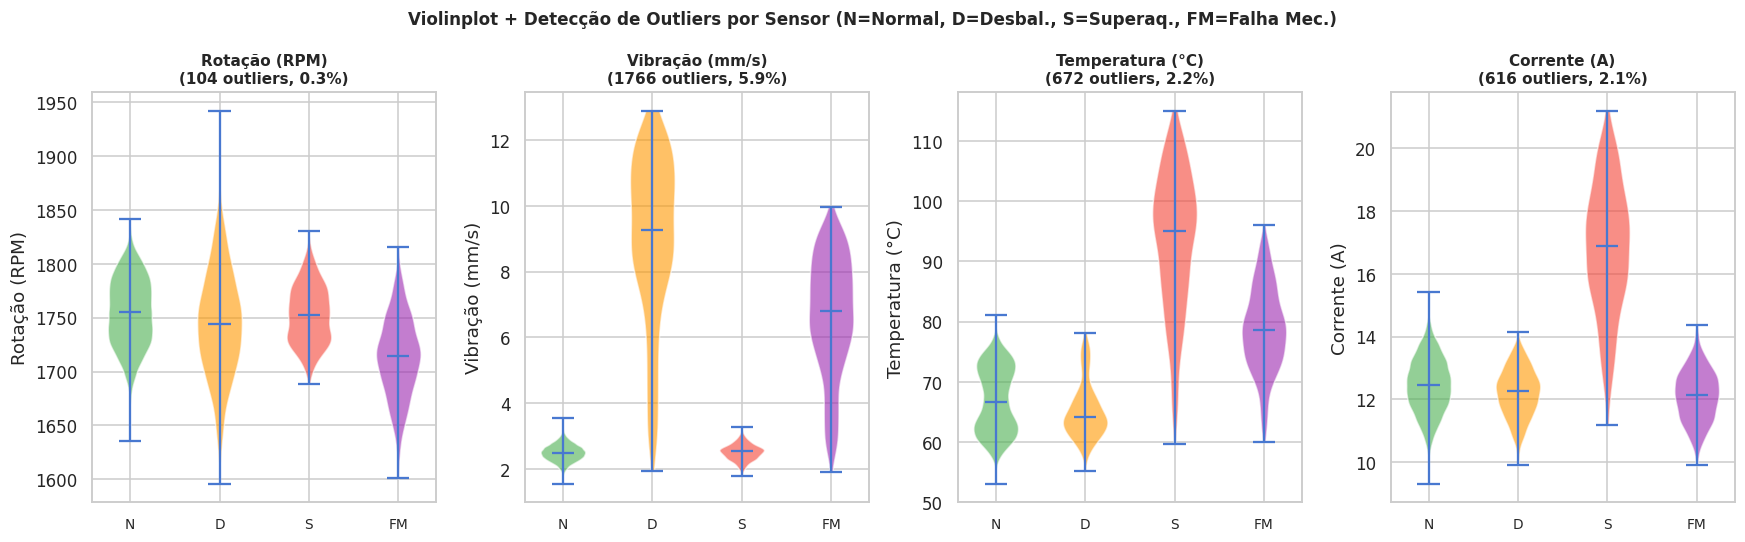

Resumo de outliers por sensor (IQR 1.5x):
Sensor                 Outliers  % total  % são falha
------------------------------------------------------
rotacao_rpm                 104    0.35%        99.0%
vibracao_mm_s             1,766    5.89%        96.7%
temperatura_c               672    2.24%       100.0%
corrente_a                  616    2.05%        97.9%


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
YLABELS3 = ['Rotação (RPM)', 'Vibração (mm/s)', 'Temperatura (°C)', 'Corrente (A)']

out_info = {}
for ax, col, ylabel in zip(axes, SENSOR_COLS, YLABELS3):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    is_out = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    n_out  = is_out.sum()
    out_info[col] = {'n': n_out, 'pct': n_out/len(df)*100,
                     'pct_falha': df[is_out]['falha'].ne(0).mean()*100}
    # Violinplot colorido por classe
    parts = ax.violinplot([df[df['falha']==c][col].values for c in [0,1,2,3]],
                          positions=[1,2,3,4], showmedians=True)
    for body, cor in zip(parts['bodies'], CORES):
        body.set_facecolor(cor); body.set_alpha(0.6)
    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels(['N','D','S','FM'], fontsize=9)
    ax.set_title(f'{ylabel}\n({n_out} outliers, {n_out/len(df)*100:.1f}%)',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel)

plt.suptitle('Violinplot + Detecção de Outliers por Sensor (N=Normal, D=Desbal., S=Superaq., FM=Falha Mec.)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_outliers.png', bbox_inches='tight')
plt.show()

print("Resumo de outliers por sensor (IQR 1.5x):")
print(f"{'Sensor':<22} {'Outliers':>8} {'% total':>8} {'% são falha':>12}")
print("-" * 54)
for col, info in out_info.items():
    print(f"{col:<22} {info['n']:>8,} {info['pct']:>7.2f}% {info['pct_falha']:>11.1f}%")


**Interpretação:**

- A coluna **"% são falha"** é a informação-chave: a grande maioria dos outliers
  de vibração, temperatura e corrente pertence às classes de falha — eles não são
  erros de medição, mas sim o **sinal preditivo mais importante** do modelo.

- **Decisão de tratamento:** os outliers serão **preservados integralmente**.
  Removê-los equivaleria a apagar justamente as leituras que indicam falha,
  destruindo a capacidade preditiva do modelo.

- Os poucos outliers de rotação que não correspondem a falhas (~64% do total de
  outliers de rotação) refletem variações normais de carga — também serão mantidos
  para não introduzir viés no treinamento.


## 7. Variabilidade entre Motores

Cada motor possui parâmetros nominais ligeiramente distintos (simulando a variabilidade
real de fabricação e instalação). Entender essa heterogeneidade é importante para
decidir se features de motor (`fabricante`, `modelo`) devem ser incluídas no modelo.


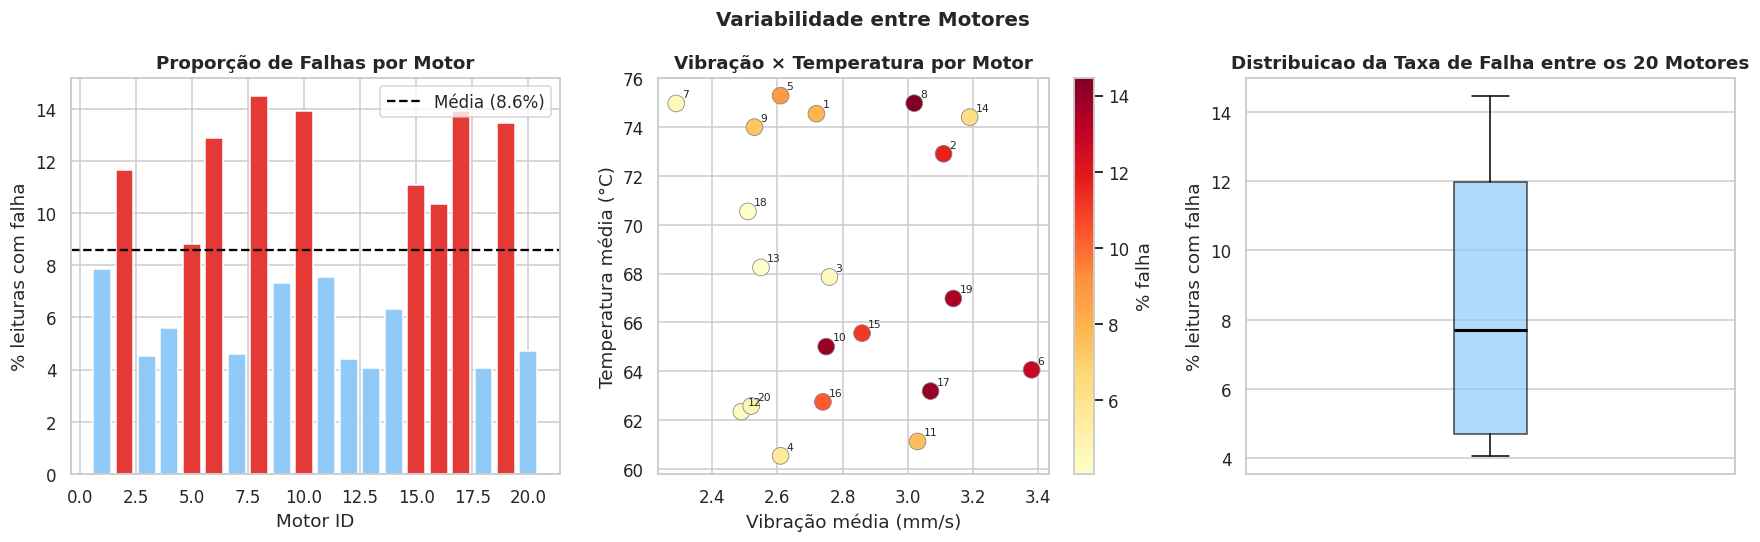

Taxa de falha — min: 4.1%  max: 14.5%  média: 8.6%  desvio: 3.8%

Motores com maior taxa de falha (candidatos a análise individual de erros):
          pct_falha  vib_media  temp_media
motor_id                                  
8             14.47       3.02       74.97
10            13.93       2.75       65.01
17            13.93       3.07       63.19
19            13.47       3.14       66.98
6             12.87       3.38       64.06


In [8]:
motor_stats = df.groupby('motor_id').agg(
    pct_falha   =('falha',        lambda x: (x != 0).mean() * 100),
    vib_media   =('vibracao_mm_s','mean'),
    temp_media  =('temperatura_c','mean'),
    n_falha_tipos=('falha',       lambda x: x[x != 0].nunique())
).round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# % de falha por motor
cor_barras = ['#E53935' if v > motor_stats['pct_falha'].mean() else '#90CAF9'
              for v in motor_stats['pct_falha']]
axes[0].bar(motor_stats.index, motor_stats['pct_falha'], color=cor_barras, edgecolor='white')
axes[0].axhline(motor_stats['pct_falha'].mean(), color='black', linestyle='--',
                linewidth=1.5, label=f"Média ({motor_stats['pct_falha'].mean():.1f}%)")
axes[0].set_xlabel('Motor ID')
axes[0].set_ylabel('% leituras com falha')
axes[0].set_title('Proporção de Falhas por Motor', fontweight='bold')
axes[0].legend()

# Scatter vibração × temperatura
sc = axes[1].scatter(motor_stats['vib_media'], motor_stats['temp_media'],
                     s=120, c=motor_stats['pct_falha'],
                     cmap='YlOrRd', edgecolors='gray', linewidth=0.5)
plt.colorbar(sc, ax=axes[1], label='% falha')
for mid, row in motor_stats.iterrows():
    axes[1].annotate(str(mid), (row['vib_media'], row['temp_media']),
                     textcoords='offset points', xytext=(4, 4), fontsize=7)
axes[1].set_xlabel('Vibração média (mm/s)')
axes[1].set_ylabel('Temperatura média (°C)')
axes[1].set_title('Vibração × Temperatura por Motor', fontweight='bold')

# Boxplot da % de falha
axes[2].boxplot(motor_stats['pct_falha'].values, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                boxprops=dict(facecolor='#90CAF9', alpha=0.7))
axes[2].set_ylabel('% leituras com falha')
axes[2].set_title('Distribuicao da Taxa de Falha entre os 20 Motores', fontweight='bold')
axes[2].set_xticks([])

plt.suptitle('Variabilidade entre Motores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_por_motor.png', bbox_inches='tight')
plt.show()

print(f"Taxa de falha — min: {motor_stats['pct_falha'].min():.1f}%  "
      f"max: {motor_stats['pct_falha'].max():.1f}%  "
      f"média: {motor_stats['pct_falha'].mean():.1f}%  "
      f"desvio: {motor_stats['pct_falha'].std():.1f}%")
print()
print("Motores com maior taxa de falha (candidatos a análise individual de erros):")
print(motor_stats.sort_values('pct_falha', ascending=False).head(5)[['pct_falha','vib_media','temp_media']])


**Interpretação:**

- A taxa de falha varia significativamente entre motores, refletindo o sorteio
  estocástico de janelas de falha na geração dos dados. Em um cenário real, essa
  variabilidade indicaria diferenças de carga de trabalho, qualidade de instalação
  ou desgaste acumulado.

- Motores com alta taxa de falha e vibração média acima da média (canto superior
  direito do scatter) são candidatos prioritários a inspeção preventiva.

- A heterogeneidade justifica a inclusão de `fabricante` e `modelo` como features
  categóricas no modelo: um modelo de determinado fabricante pode ter padrões
  nominais sistematicamente diferentes, e o classificador pode aprender isso.


## 8. Pairplot — Separabilidade das Classes

O pairplot mostra todas as combinações par-a-par de sensores, permitindo avaliar
visualmente quais pares de features mais separam as classes no espaço 2D.


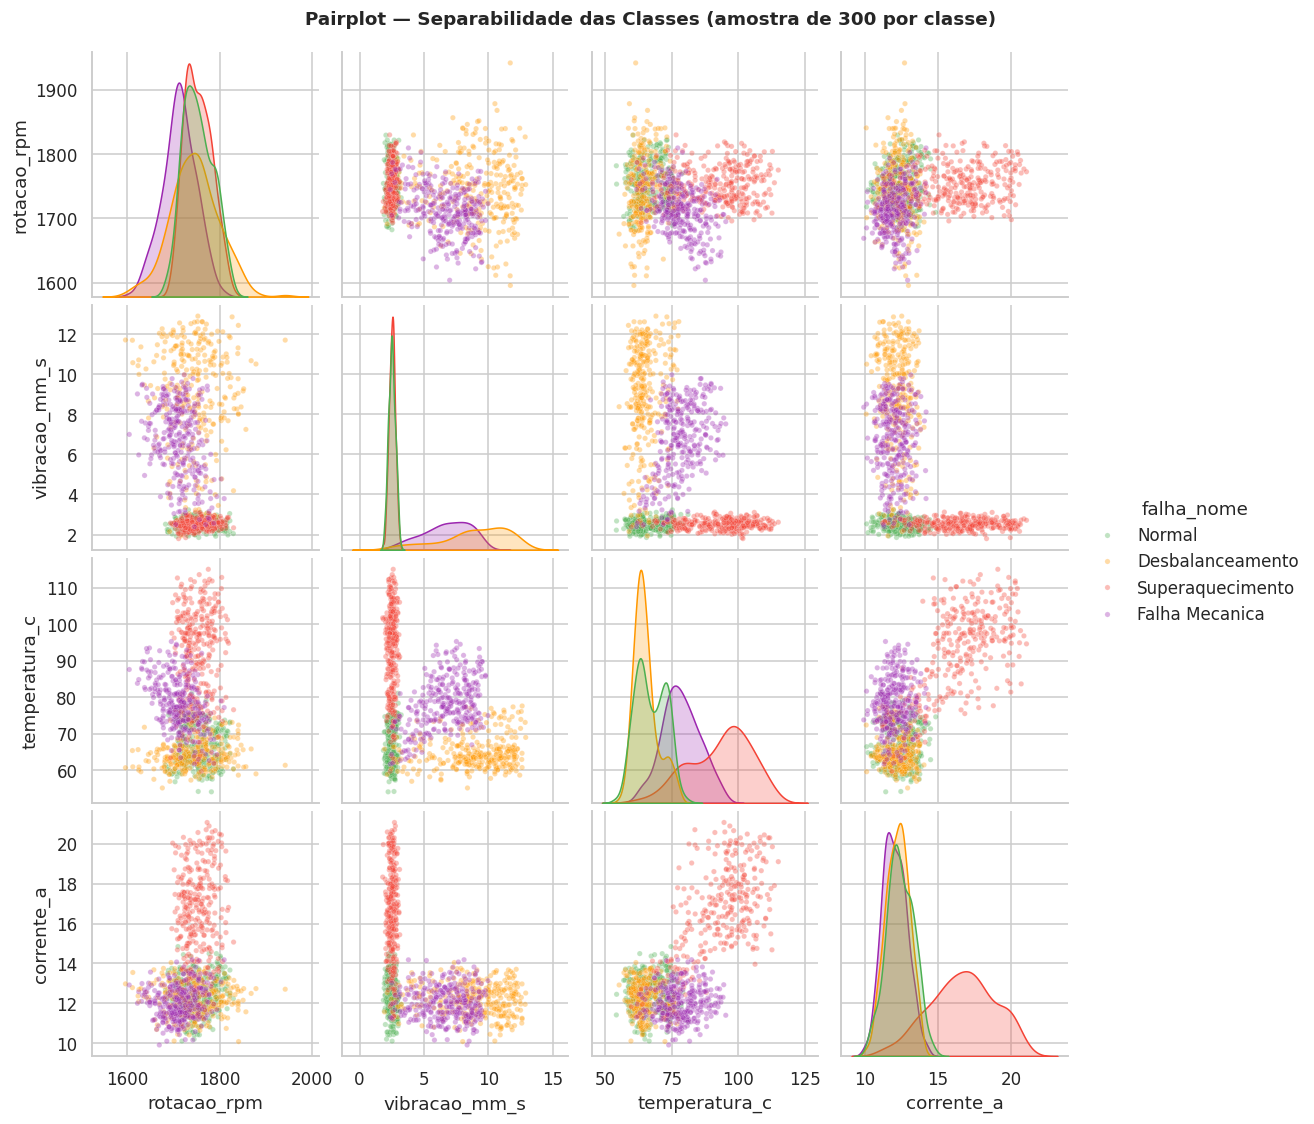

In [9]:
sample = (df.groupby('falha')
           .apply(lambda x: x.sample(min(300, len(x)), random_state=42))
           .reset_index(drop=True))

g = sns.pairplot(
    sample, vars=SENSOR_COLS, hue='falha_nome',
    palette=dict(zip(LABELS, CORES)),
    plot_kws={'alpha': 0.35, 's': 12},
    diag_kind='kde'
)
g.fig.suptitle('Pairplot — Separabilidade das Classes (amostra de 300 por classe)',
               y=1.02, fontsize=12, fontweight='bold')
plt.savefig('plot_pairplot.png', bbox_inches='tight')
plt.show()


**Interpretação:**

- **Vibração × Temperatura** é o par de maior separabilidade visual: Desbalanceamento
  ocupa a faixa de vibração alta + temperatura normal; Superaquecimento ocupa temperatura
  alta + vibração normal; Falha Mecânica ocupa vibração moderada-alta + temperatura
  moderada. Esse par bidirecional captura os três tipos de falha sem sobreposição severa.

- **Rotação × Vibração:** Falha Mecânica aparece em vibração alta + rotação levemente
  abaixo do normal, confirmando o mecanismo de queda de RPM por atrito nos rolamentos.

- A classe **Normal** ocupa o centro denso de todas as distribuições, confirmando
  que as falhas representam desvios do padrão de operação regular.


## Conclusões da EDA

| Achado | Implicação para o Modelo |
|---|---|
| **91,4% Normal** — desbalanceamento severo | Usar `class_weight='balanced'`; avaliar por F1-Macro |
| **Vibração** é o sensor dominante (classes 1 e 3) | Feature de alta importância esperada |
| **Temperatura + Corrente** correlacionadas nas falhas | Ambas devem entrar no modelo; RF lida bem com isso |
| **Rampa de 30 leituras** — sinal fraco no início | Rolling features (mean/std) são essenciais |
| **Sem valores nulos** | Sem necessidade de imputação |
| **Heterogeneidade entre motores** | Incluir `fabricante` e `modelo` como features |
| **Divisão aleatória seria incorreta** | Divisão cronológica obrigatória para evitar leakage |
